# NIFTY-50 AI Investment Intelligence Pipeline
This notebook consolidates the entire end-to-end machine learning and data science pipeline.
It covers:
1. Data Loading & Cleaning
2. Feature Engineering (Technical Indicators)
3. Model Training (XGBoost Classifier & Regressor + SHAP)
4. Risk Assessment & Portfolio Construction
5. Anomaly Detection

## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import joblib
import shap
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set working directory to project root (important when running inside 'notebooks' folder)
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

## 2. Data Loading & Cleaning (Phase 1)

In [4]:
print("Loading data...")
all_files = glob.glob("data/*.csv")
data_frames = []

for file in all_files:
    if "cleaned_data" in file or "featured_data" in file or "risk_profiles" in file:
        continue
    try:
        df = pd.read_csv(file)
        if "Symbol" in df.columns and "Date" in df.columns:
            data_frames.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

raw_df = pd.concat(data_frames, ignore_index=True)
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
raw_df = raw_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(f"Total rows loaded: {len(raw_df)}")
print(f"Total companies: {raw_df['Symbol'].nunique()}")

Loading data...
Total rows loaded: 470384
Total companies: 65


## 3. Feature Engineering (Phase 2)
Calculating Moving Averages, RSI, Bollinger Bands, and MACD.

In [5]:
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def feature_engineering(df):
    df["MA_20"] = df.groupby("Symbol")["Close"].transform(lambda x: x.rolling(20).mean())
    df["MA_50"] = df.groupby("Symbol")["Close"].transform(lambda x: x.rolling(50).mean())
    df["MA_200"] = df.groupby("Symbol")["Close"].transform(lambda x: x.rolling(200).mean())
    
    df["RSI"] = df.groupby("Symbol")["Close"].transform(compute_rsi)
    
    # MACD
    ema_12 = df.groupby("Symbol")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema_26 = df.groupby("Symbol")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df["MACD"] = ema_12 - ema_26
    df["MACD_Signal"] = df.groupby("Symbol")["MACD"].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]
    
    # Bollinger Bands
    df["BB_Mid"] = df["MA_20"]
    std_20 = df.groupby("Symbol")["Close"].transform(lambda x: x.rolling(20).std())
    df["BB_Upper"] = df["BB_Mid"] + (std_20 * 2)
    df["BB_Lower"] = df["BB_Mid"] - (std_20 * 2)
    df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / df["BB_Mid"]
    
    df["Daily_Return"] = df.groupby("Symbol")["Close"].pct_change()
    df["Daily_Return"] = pd.to_numeric(df["Daily_Return"], errors="coerce")
    df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    df["Volatility_20"] = df.groupby("Symbol")["Daily_Return"].transform(lambda x: x.rolling(20).std())
    
    # Target Variables
    df["Next_Close"] = df.groupby("Symbol")["Close"].shift(-1)
    df["Target_Direction"] = (df["Next_Close"] > df["Close"]).astype(int)
    
    return df

features_df = feature_engineering(raw_df.copy())
features_df.to_csv("data/featured_data.csv", index=False)
print("Feature engineering complete and saved to data/featured_data.csv!")

Feature engineering complete and saved to data/featured_data.csv!


## 4. Machine Learning: Stock Predictor (Phase 3A)
Training XGBoost Classifier for direction (UP/DOWN) and Regressor for exact price prediction.

In [6]:
feature_cols = [
    "RSI", "MACD", "MACD_Signal", "MACD_Hist",
    "MA_20", "MA_50", "BB_Width", "Volatility_20",
    "Daily_Return", "Volume"
]

def train_and_save_models(df, symbol):
    stock_df = df[df["Symbol"] == symbol].copy()
    stock_df = stock_df.dropna(subset=feature_cols + ["Next_Close", "Target_Direction"])
    
    if len(stock_df) < 100:
        return None, None
        
    X = stock_df[feature_cols].values
    y_class = stock_df["Target_Direction"].values
    y_reg = stock_df["Next_Close"].values
    
    # Chronological Split (80% Train, 20% Test) to prevent data leakage
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    yc_train, yc_test = y_class[:split], y_class[split:]
    yr_train, yr_test = y_reg[:split], y_reg[split:]
    
    # Train Classifier
    clf = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=1, random_state=42)
    clf.fit(X_train, yc_train)
    acc = accuracy_score(yc_test, clf.predict(X_test))
    joblib.dump(clf, f"models/xgboost_{symbol}.pkl")
    
    # Train Regressor
    reg = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=1, random_state=42)
    reg.fit(X_train, yr_train)
    rmse = np.sqrt(mean_squared_error(yr_test, reg.predict(X_test)))
    joblib.dump(reg, f"models/xgboost_reg_{symbol}.pkl")
    
    return acc, rmse

print("Training models for ALL stocks and saving them for the Streamlit dashboard...")
all_symbols = features_df["Symbol"].unique()
results = []

for sym in all_symbols:
    if sym in features_df["Symbol"].values:
        acc, rmse = train_and_save_models(features_df, sym)
        if acc:
            results.append({"Symbol": sym, "Testing_Accuracy": acc, "Price_RMSE": rmse})
            if len(results) % 10 == 0:
                print(f"Trained {len(results)}/{len(all_symbols)} stocks...")

results_df = pd.DataFrame(results)
print("\n--- MODEL TRAINING COMPLETE ---")
print("Top 10 Stocks by Testing Accuracy on Unseen Data:")
print(results_df.sort_values("Testing_Accuracy", ascending=False).head(10))

Training models for ALL stocks and saving them for the Streamlit dashboard...
Trained 10/65 stocks...
Trained 20/65 stocks...
Trained 30/65 stocks...
Trained 40/65 stocks...
Trained 50/65 stocks...
Trained 60/65 stocks...

--- MODEL TRAINING COMPLETE ---
Top 10 Stocks by Testing Accuracy on Unseen Data:
        Symbol  Testing_Accuracy  Price_RMSE
35    KOTAKMAH          0.780105    6.604070
21  HEROMOTOCO          0.773585   69.874354
43   POWERGRID          0.765367    4.383510
26   ICICIBANK          0.764789   10.822732
25  HINDUNILVR          0.764749  401.554363
59         UPL          0.764305   21.059898
61        VEDL          0.763293    5.849174
17     HCLTECH          0.763033   25.269423
37         M&M          0.761477   37.052957
19    HDFCBANK          0.760057   68.321359


## 5. Explainable AI (SHAP)
Understanding what drives the AI predictions.

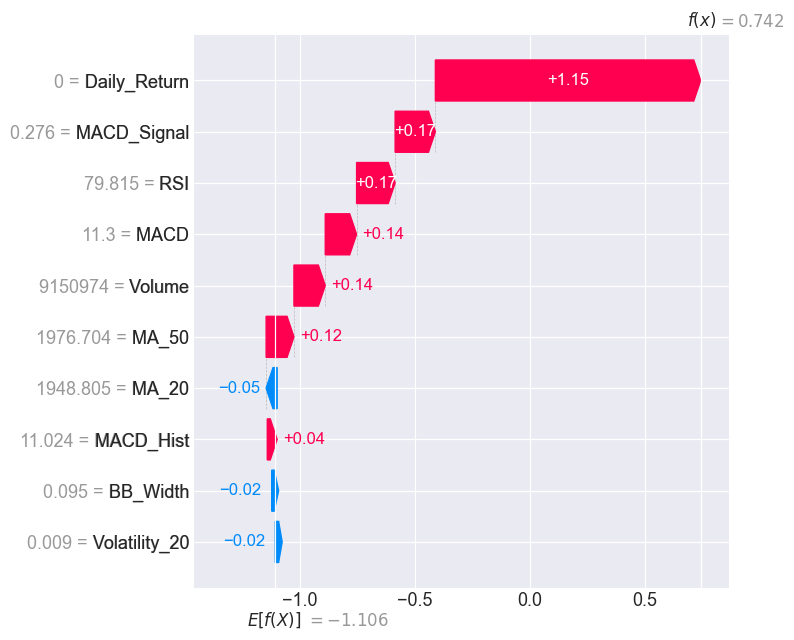

In [7]:
sample_stock = "RELIANCE"
stock_df = features_df[features_df["Symbol"] == sample_stock].dropna(subset=feature_cols + ["Target_Direction"])
X = stock_df[feature_cols].values
y = stock_df["Target_Direction"].values

model = joblib.load(f"models/xgboost_{sample_stock}.pkl")
explainer = shap.TreeExplainer(model)
X_shap = stock_df[feature_cols].apply(pd.to_numeric, errors='coerce')
shap_values = explainer(X_shap)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[-1], show=False)
plt.tight_layout()
plt.show()

## 6. Risk Assessment & Portfolio Construction (Phase 3B & 4A)

Risk assessment complete and saved to data/risk_profiles.csv!


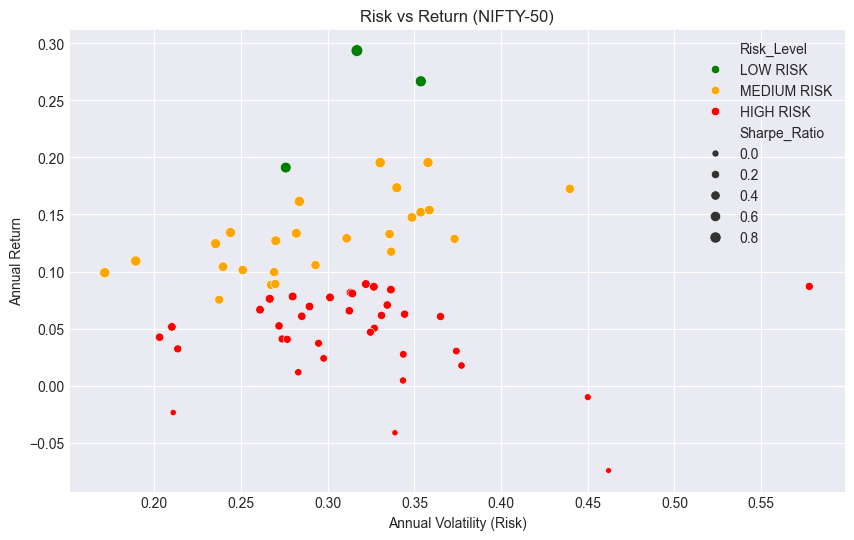

        Symbol  Annual_Return  Annual_Volatility  Sharpe_Ratio  Max_Drawdown  \
7       BHARTI       0.293696           0.316838      0.926960     -0.541943   
59     UTIBANK       0.266750           0.353695      0.754180     -0.590194   
46    SHREECEM       0.191129           0.275770      0.693073     -0.799734   
6   BAJFINANCE       0.195487           0.330261      0.591916     -0.932820   
39   NESTLEIND       0.098955           0.171387      0.577375     -0.324011   
25  HINDUNILVR       0.109199           0.189214      0.577118     -0.267812   
4   BAJAJFINSV       0.161549           0.283645      0.569546     -0.867894   
37      MARUTI       0.134200           0.243934      0.550149     -0.613397   
5   BAJAUTOFIN       0.195568           0.357820      0.546554     -0.918020   
56  ULTRACEMCO       0.124463           0.235319      0.528912     -0.777797   

     Risk_Level  
7      LOW RISK  
59     LOW RISK  
46     LOW RISK  
6   MEDIUM RISK  
39  MEDIUM RISK  
25  MEDIUM 

In [8]:
def assess_risk(df):
    risk_metrics = []
    for sym in df["Symbol"].unique():
        sym_df = df[df["Symbol"] == sym]
        returns = sym_df["Daily_Return"].dropna()
        if len(returns) < 252:
            continue
            
        ann_return = returns.mean() * 252
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else 0
        
        cumulative = (1 + returns).cumprod()
        peak = cumulative.cummax()
        drawdown = (cumulative - peak) / peak
        max_dd = drawdown.min()
        
        # Realistic thresholds for Emerging Markets
        if sharpe > 0.6:
            risk_level = "LOW RISK"
        elif sharpe > 0.3:
            risk_level = "MEDIUM RISK"
        else:
            risk_level = "HIGH RISK"
            
        risk_metrics.append({
            "Symbol": sym,
            "Annual_Return": ann_return,
            "Annual_Volatility": ann_vol,
            "Sharpe_Ratio": sharpe,
            "Max_Drawdown": max_dd,
            "Risk_Level": risk_level
        })
        
    return pd.DataFrame(risk_metrics).sort_values("Sharpe_Ratio", ascending=False)

risk_df = assess_risk(features_df)
risk_df.to_csv("data/risk_profiles.csv", index=False)
print("Risk assessment complete and saved to data/risk_profiles.csv!")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=risk_df, x="Annual_Volatility", y="Annual_Return", size="Sharpe_Ratio", hue="Risk_Level", palette={"LOW RISK": "green", "MEDIUM RISK": "orange", "HIGH RISK": "red"})
plt.title("Risk vs Return (NIFTY-50)")
plt.xlabel("Annual Volatility (Risk)")
plt.ylabel("Annual Return")
plt.show()

print(risk_df.head(10))

## 7. Anomaly Detection (Phase 4B)

Detected 150 extreme price moves for RELIANCE


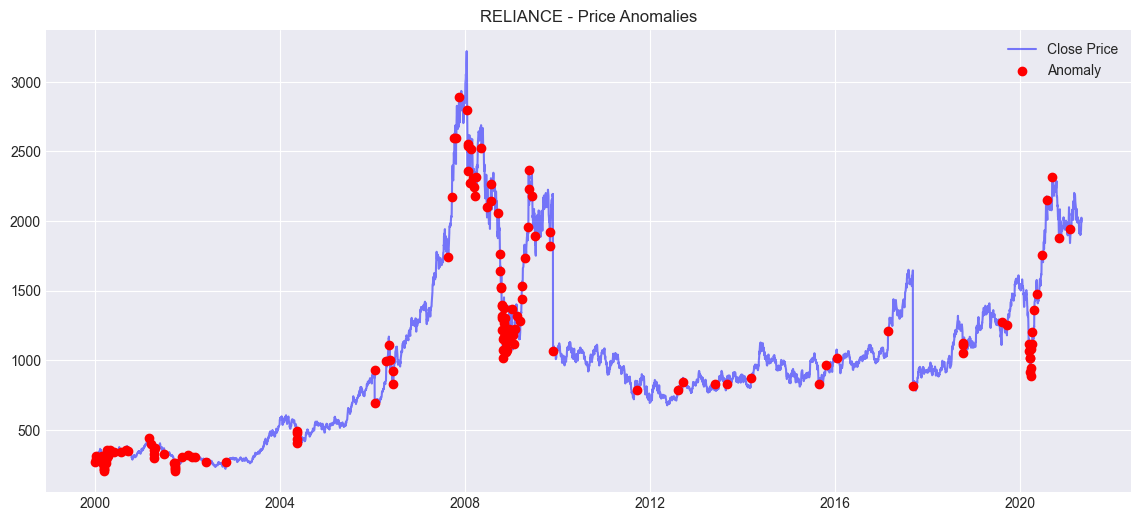

In [9]:
stock = "RELIANCE"
df_anomaly = features_df[features_df["Symbol"] == stock].copy().dropna(subset=["Daily_Return", "Volume"])

mean_ret = df_anomaly["Daily_Return"].mean()
std_ret = df_anomaly["Daily_Return"].std()
df_anomaly["Price_Anomaly"] = np.abs(df_anomaly["Daily_Return"] - mean_ret) > (3 * std_ret)

df_anomaly["Vol_MA"] = df_anomaly["Volume"].rolling(20).mean()
df_anomaly["Volume_Anomaly"] = df_anomaly["Volume"] > (df_anomaly["Vol_MA"] * 2.5)

price_anomalies = df_anomaly[df_anomaly["Price_Anomaly"]]
print(f"Detected {len(price_anomalies)} extreme price moves for {stock}")

plt.figure(figsize=(14, 6))
plt.plot(df_anomaly["Date"], df_anomaly["Close"], label="Close Price", color="blue", alpha=0.5)
plt.scatter(price_anomalies["Date"], price_anomalies["Close"], color="red", label="Anomaly", zorder=5)
plt.title(f"{stock} - Price Anomalies")
plt.legend()
plt.show()

---
*End of Pipeline. The models and data are now saved!*
*To view the interactive Web Dashboard, run `streamlit run src/phase5_dashboard.py` in your terminal.*